In [7]:
pip install numpy

   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   --------------------------------- ------ 10.5/12.6 MB 55.4 MB/s eta 0:00:01
   ---------------------------------------- 12.6/12.6 MB 53.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


### Random Forest

In [1]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from micromlgen import port


data = pd.read_csv('data1.txt', header=None)
data.rename(columns={data.columns[-1]: 'Label'}, inplace=True)
data = data[(data['Label'] != 'L') & (data['Label'] != 'R') & (data['Label'] != 'H') & (data['Label'] != 'J')]
data.reset_index(drop=True, inplace=True)
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

k = 80
k_best = SelectKBest(score_func=f_classif, k=k)
k_best.fit(X_train, y_train)

selected_feature_indices = k_best.get_support(indices=True)
print("selected_feature_indices: ", selected_feature_indices)


rf = RandomForestClassifier(max_depth=2, random_state=42)
rf.fit(X_train.iloc[:, selected_feature_indices], y_train)

y_pred = rf.predict(X_test.iloc[:, selected_feature_indices])

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

class_names = label_encoder.classes_
report = classification_report(y_test, y_pred, target_names=class_names, zero_division=0)
print('Classification Report:\n', report)

# arduino_code = open("arduino_random_forest10.c", mode="w+")
# arduino_code.write(port(clf))

selected_feature_indices:  [135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152
 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170
 171 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199 200 201
 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217 218 219
 220 221 222 223 224 225 226 227]
Accuracy: 0.7847025495750708
Classification Report:
               precision    recall  f1-score   support

           F       0.79      0.93      0.86       241
           G       0.78      0.55      0.65        58
           I       0.74      0.37      0.49        54

    accuracy                           0.78       353
   macro avg       0.77      0.62      0.67       353
weighted avg       0.78      0.78      0.77       353



#### Decision Tree

In [2]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.metrics import accuracy_score, classification_report
from micromlgen import port

data = pd.read_csv('data1.txt', header=None)
data.rename(columns={data.columns[-1]: 'Label'}, inplace=True)
data = data[(data['Label'] != 'L') & (data['Label'] != 'R') & (data['Label'] != 'H')]
data.reset_index(drop=True, inplace=True)
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

k = 80
k_best = SelectKBest(score_func=f_classif, k=k)
k_best.fit(X_train, y_train)

selected_feature_indices = k_best.get_support(indices=True)
print("selected_feature_indices: ", selected_feature_indices)

dt = tree.DecisionTreeClassifier()
dt.fit(X_train.iloc[:, selected_feature_indices], y_train)

y_pred = dt.predict(X_test.iloc[:, selected_feature_indices])

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

class_names = label_encoder.classes_
report = classification_report(y_test, y_pred, target_names=class_names, zero_division=0)
print('Classification Report:\n', report)

selected_feature_indices:  [135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152
 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170
 171 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199 200 201
 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217 218 219
 220 221 222 223 224 225 226 227]
Accuracy: 0.6883852691218131
Classification Report:
               precision    recall  f1-score   support

           F       0.79      0.76      0.78       241
           G       0.55      0.59      0.57        58
           I       0.43      0.48      0.46        54

    accuracy                           0.69       353
   macro avg       0.59      0.61      0.60       353
weighted avg       0.70      0.69      0.69       353



#### Imbalance Plot

C:\Users\russo\AppData\Local\Temp\ipykernel_14828\2742676028.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index.astype(str), y=class_counts.values, palette='deep')


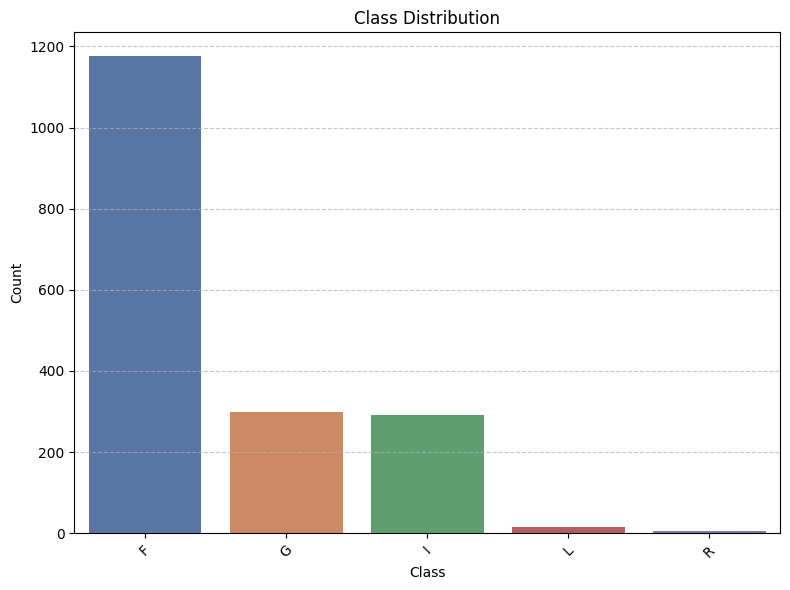

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('data1.txt', header=None)
labels = data.iloc[:, -1]
class_counts = labels.value_counts()


plt.figure(figsize=(8, 6))
sns.barplot(x=class_counts.index.astype(str), y=class_counts.values, palette='deep')

plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()